# Research Notebook: Pairs Trading
Based on "Pairs Trading in Crypto" by Stoikov, et al. (2025)

### Imports

In [1]:
import requests
import pandas as pd
import numpy as np
import time
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import json
import os
import pickle
import itertools
import statsmodels.api as sm
from statsmodels.regression.rolling import RollingOLS
from statsmodels.tsa.stattools import coint
from tqdm.notebook import tqdm

plt.style.use('dark_background')
pd.set_option('display.float_format', '{:.6f}'.format)

### Fetching candlestick data from Binance
Fetch historical price data for (nearly) all coins available on Roostoo. Coins are categorized following research paper methodology.

In [2]:
CATEGORIZED_SYMBOLS = {
    "layer_1": {
        "BTC": "BTCUSDT", "ETH": "ETHUSDT", "SOL": "SOLUSDT", "BNB": "BNBUSDT",
        "ADA": "ADAUSDT", "TRX": "TRXUSDT", "DOT": "DOTUSDT", "SUI": "SUIUSDT",
        "NEAR": "NEARUSDT", "AVAX": "AVAXUSDT", "TON": "TONUSDT", "XRP": "XRPUSDT",
        "DOGE": "DOGEUSDT", "LTC": "LTCUSDT", "APT": "APTUSDT", "HBAR": "HBARUSDT",
        "XLM": "XLMUSDT", "SEI": "SEIUSDT", "ICP": "ICPUSDT", "CFX": "CFXUSDT",
        "ZEC": "ZECUSDT", "ZEN": "ZENUSDT"
    },
    "layer_2": {
        "POL": "POLUSDT", "ARB": "ARBUSDT", "OMNI": "OMNIUSDT", "LINEA": "LINEAUSDT",
        "HEMI": "HEMIUSDT"
    },
    "defi": {
        "AAVE": "AAVEUSDT", "ENA": "ENAUSDT", "UNI": "UNIUSDT", "LINK": "LINKUSDT",
        "CRV": "CRVUSDT", "CAKE": "CAKEUSDT", "LISTA": "LISTAUSDT", "WLFI": "WLFIUSDT"
    },
    "liquid_staking_restaking": {
        "PENDLE": "PENDLEUSDT", "EIGEN": "EIGENUSDT"
    },
    "memes": {
        "PEPE": "PEPEUSDT", "SHIB": "SHIBUSDT", "WIF": "WIFUSDT", "BONK": "BONKUSDT",
        "FLOKI": "FLOKIUSDT", "PUMP": "PUMPUSDT", "1000CHEEMS": "1000CHEEMSUSDT", 
        "PENGU": "PENGUUSDT", "TRUMP": "TRUMPUSDT"
    },
    "ai_and_depin": {
        "FET": "FETUSDT", "TAO": "TAOUSDT", "FIL": "FILUSDT", "WLD": "WLDUSDT", 
        "VIRTUAL": "VIRTUALUSDT"
    },
    "rwa_and_others": {
        "PAXG": "PAXGUSDT", "ONDO": "ONDOUSDT", "PLUME": "PLUMEUSDT", "BIO": "BIOUSDT",
        "OPEN": "OPENUSDT", "S": "SUSDT", "AVNT": "AVNTUSDT", "EDEN": "EDENUSDT",
        "FORM": "FORMUSDT", "BMT": "BMTUSDT", "ASTER": "ASTERUSDT", "STO": "STOUSDT",
        "SOMI": "SOMIUSDT", "XPL": "XPLUSDT", "TUT": "TUTUSDT", "MIRA": "MIRAUSDT"
    }
}

# Flatten the nested dictionary for the data fetcher
SYMBOLS = {}
for category, tokens in CATEGORIZED_SYMBOLS.items():
    for name, ticker in tokens.items():
        SYMBOLS[name] = ticker

print(f"Number of symbols: {len(SYMBOLS)}")

INTERVAL  = "1h"
DAYS_BACK = 365

BASE_URL = "https://api.binance.com/api/v3/klines"

Number of symbols: 67


In [5]:
def fetch_binance_klines(symbol: str, interval: str, days: int) -> pd.DataFrame:
    """
    Fetch historical kline (candlestick) data from Binance public API.
    No API key required.

    Automatically paginates through the 1000-candle-per-request limit
    so you can fetch arbitrarily long histories (e.g. 30 days of 1m data).

    Returns a DataFrame with columns:
        open_time, open, high, low, close, volume, close_time
    """
    end_ms   = int(time.time() * 1000)
    start_ms = int((time.time() - days * 86400) * 1000)
    limit    = 1000

    all_rows = []
    cursor   = start_ms

    while cursor < end_ms:
        params = {
            "symbol":    symbol,
            "interval":  interval,
            "startTime": cursor,
            "endTime":   end_ms,
            "limit":     limit,
        }
        resp = requests.get(BASE_URL, params=params)
        resp.raise_for_status()
        batch = resp.json()

        if not batch:
            break

        all_rows.extend(batch)
        # advance cursor past the last candle's open_time
        cursor = batch[-1][0] + 1
        time.sleep(0.1)  # rate-limit courtesy

    cols = [
        "open_time", "open", "high", "low", "close", "volume",
        "close_time", "quote_vol", "trades", "taker_buy_base",
        "taker_buy_quote", "ignore",
    ]
    df = pd.DataFrame(all_rows, columns=cols)
    df["open_time"]  = pd.to_datetime(df["open_time"],  unit="ms")
    df["close_time"] = pd.to_datetime(df["close_time"], unit="ms")

    for col in ["open", "high", "low", "close", "volume"]:
        df[col] = df[col].astype(float)

    return df[["open_time", "open", "high", "low", "close", "volume", "close_time"]]

In [6]:
CACHE_FILE = f"klines_cache_{DAYS_BACK}d.pkl"

if os.path.exists(CACHE_FILE):
    print(f"Loading cached data from {CACHE_FILE}...")
    with open(CACHE_FILE, "rb") as f:
        raw_data = pickle.load(f)
else:
    raw_data = {}

# ── Pull data for every symbol ────────────────────────────────
for name, ticker in SYMBOLS.items():
    if name in raw_data and len(raw_data[name]) > 0:
        print(f"Loaded cached {name:5s} ({ticker}) ... {len(raw_data[name])} candles")
    else:
        print(f"Fetching {name:5s} ({ticker}) ...", end=" ")
        raw_data[name] = fetch_binance_klines(ticker, INTERVAL, DAYS_BACK)
        print(f"{len(raw_data[name])} candles")
        with open(CACHE_FILE, "wb") as f:
            pickle.dump(raw_data, f)

print("\n✅ All data loaded successfully.")

Fetching BTC   (BTCUSDT) ... 8760 candles
Fetching ETH   (ETHUSDT) ... 8760 candles
Fetching SOL   (SOLUSDT) ... 8760 candles
Fetching BNB   (BNBUSDT) ... 8760 candles
Fetching ADA   (ADAUSDT) ... 8760 candles
Fetching TRX   (TRXUSDT) ... 8760 candles
Fetching DOT   (DOTUSDT) ... 8760 candles
Fetching SUI   (SUIUSDT) ... 8760 candles
Fetching NEAR  (NEARUSDT) ... 8760 candles
Fetching AVAX  (AVAXUSDT) ... 8760 candles
Fetching TON   (TONUSDT) ... 8760 candles
Fetching XRP   (XRPUSDT) ... 8760 candles
Fetching DOGE  (DOGEUSDT) ... 8760 candles
Fetching LTC   (LTCUSDT) ... 8760 candles
Fetching APT   (APTUSDT) ... 8760 candles
Fetching HBAR  (HBARUSDT) ... 8760 candles
Fetching XLM   (XLMUSDT) ... 8760 candles
Fetching SEI   (SEIUSDT) ... 8760 candles
Fetching ICP   (ICPUSDT) ... 8760 candles
Fetching CFX   (CFXUSDT) ... 8760 candles
Fetching ZEC   (ZECUSDT) ... 8760 candles
Fetching ZEN   (ZENUSDT) ... 8760 candles
Fetching POL   (POLUSDT) ... 8760 candles
Fetching ARB   (ARBUSDT) ... 8

In [142]:
# Calculate expected candles based on hours per day (24)
EXPECTED_CANDLES = DAYS_BACK * 24 

# How many days of data we want to train & test this on
DAYS = 365

close_prices = pd.DataFrame({
    name: df.set_index("open_time")["close"]
    for name, df in raw_data.items() 
    if name in SYMBOLS and len(df) >= EXPECTED_CANDLES
})

close_prices.index.name = "date"
close_prices = close_prices.dropna()

cutoff_date = close_prices.index.max() - pd.Timedelta(days=DAYS)
close_prices = close_prices[close_prices.index >= cutoff_date]

print(f"Close prices shape: {close_prices.shape}")
close_prices.head()

Close prices shape: (8760, 50)


,BTC,ETH,SOL,BNB,ADA,TRX,DOT,SUI,NEAR,AVAX,...,TRUMP,FET,TAO,FIL,WLD,PAXG,BIO,S,FORM,BMT
date,,,,,,,,,,,,,,,,,,,,,
2025-03-21 04:00:00,84662.740000,1983.340000,128.440000,630.840000,0.720100,0.231500,4.546000,2.328800,2.746000,18.930000,...,11.050000,0.530000,255.800000,3.037000,0.858000,3062.000000,0.086100,0.507900,1.819100,0.199600
2025-03-21 05:00:00,84469.660000,1974.430000,128.280000,633.500000,0.719400,0.231600,4.530000,2.312400,2.745000,19.000000,...,11.040000,0.527000,253.800000,3.009000,0.851000,3058.000000,0.085800,0.504200,1.779300,0.194500
2025-03-21 06:00:00,84200.000000,1973.470000,128.120000,631.010000,0.718000,0.232200,4.527000,2.303500,2.753000,18.920000,...,10.930000,0.522000,253.600000,3.003000,0.844000,3065.000000,0.085200,0.499100,1.770800,0.192600
2025-03-21 07:00:00,83937.980000,1976.780000,128.070000,629.380000,0.714100,0.233200,4.509000,2.295800,2.745000,18.760000,...,10.910000,0.519000,253.200000,2.988000,0.840000,3054.000000,0.083100,0.495300,1.782000,0.190100
2025-03-21 08:00:00,84022.320000,1974.910000,128.390000,630.090000,0.711300,0.234000,4.487000,2.281500,2.735000,18.640000,...,10.840000,0.511000,250.900000,2.971000,0.833000,3062.000000,0.081600,0.492100,1.703200,0.188600


### Get log prices & returns

In [164]:
# Split Data
split_idx = int(len(close_prices) * 0.90)
train_close_prices = close_prices.iloc[:split_idx]
test_close_prices = close_prices.iloc[split_idx:]

print(f"Train data shape: {train_close_prices.shape}")
print(f"Test data shape: {test_close_prices.shape}")

# Log prices & returns
log_prices  = np.log(train_close_prices).dropna()
log_returns = np.log(close_prices).diff().dropna()

log_returns.head()
log_prices.head()

Train data shape: (7884, 50)
Test data shape: (876, 50)


,BTC,ETH,SOL,BNB,ADA,TRX,DOT,SUI,NEAR,AVAX,...,TRUMP,FET,TAO,FIL,WLD,PAXG,BIO,S,FORM,BMT
date,,,,,,,,,,,,,,,,,,,,,
2025-03-21 04:00:00,11.346431,7.592538,4.855462,6.447052,-0.328365,-1.463175,1.514248,0.845353,1.010145,2.940748,...,2.402430,-0.634878,5.544396,1.110870,-0.153151,8.026824,-2.452246,-0.677471,0.598342,-1.611440
2025-03-21 05:00:00,11.344148,7.588035,4.854215,6.451260,-0.329338,-1.462744,1.510722,0.838286,1.009781,2.944439,...,2.401525,-0.640555,5.536547,1.101608,-0.161343,8.025516,-2.455736,-0.684782,0.576220,-1.637323
2025-03-21 06:00:00,11.340950,7.587549,4.852967,6.447322,-0.331286,-1.460156,1.510059,0.834430,1.012691,2.940220,...,2.391511,-0.650088,5.535758,1.099612,-0.169603,8.027803,-2.462754,-0.694949,0.571431,-1.647140
2025-03-21 07:00:00,11.337833,7.589225,4.852577,6.444735,-0.336732,-1.455859,1.506075,0.831081,1.009781,2.931727,...,2.389680,-0.655851,5.534180,1.094604,-0.174353,8.024207,-2.487711,-0.702592,0.577736,-1.660205
2025-03-21 08:00:00,11.338838,7.588278,4.855073,6.445863,-0.340661,-1.452434,1.501184,0.824833,1.006131,2.925310,...,2.383243,-0.671386,5.525054,1.088899,-0.182722,8.026824,-2.505926,-0.709073,0.532509,-1.668127


### Generate pairs within same category

In [165]:
# 1. Generate Same-Category Pairs
candidate_pairs = []
for category, tokens in CATEGORIZED_SYMBOLS.items():
    names = list(tokens.keys())
    # Create all possible unique pairs within this specific category
    category_pairs = list(itertools.combinations(names, 2))
    candidate_pairs.extend(category_pairs)

print(f"Total candidate pairs from same categories: {len(candidate_pairs)}")

Total candidate pairs from same categories: 436


### Correlation, cointegration, IC tests

In [166]:
correlated_pairs = []
for coin_a, coin_b in tqdm(candidate_pairs, desc="Analyzing correlation of pairs..."):
    if coin_a in log_prices.columns and coin_b in log_prices.columns:
        corr_log = log_prices[coin_a].corr(log_prices[coin_b])
        corr_ret = log_returns[coin_a].corr(log_returns[coin_b])
        
        # The paper's strict thresholds
        if corr_log > 0.9 and corr_ret > 0.5:
            correlated_pairs.append((coin_a, coin_b))

print(f"Pairs surviving correlation screening: {len(correlated_pairs)}")

Analyzing correlation of pairs...:   0%|          | 0/436 [00:00<?, ?it/s]

Pairs surviving correlation screening: 58


Note: Cointegration testing was not part of the original research paper methodology, but I added it here to be more robust

In [167]:
def check_cointegration(series_a, series_b, significance_level=0.05):
    """
    Runs the Engle-Granger test for cointegration.
    Returns True if the pairs are cointegrated, along with the p-value.
    """
    # The coint function automatically runs the OLS regression and ADF test
    score, p_value, _ = coint(series_a, series_b)
    
    is_cointegrated = p_value < significance_level
    return is_cointegrated, p_value

# How to use it on your surviving correlated_pairs:
robust_pairs = []
print("Testing for strict cointegration...")

for coin_a, coin_b in correlated_pairs:
    is_coint, p_val = check_cointegration(log_prices[coin_a], log_prices[coin_b])
    
    if is_coint:
        print(f"✅ {coin_a}-{coin_b} passed (p-value: {p_val:.4f})")
        robust_pairs.append((coin_a, coin_b))
    else:
        print(f"❌ {coin_a}-{coin_b} failed (p-value: {p_val:.4f})")

print(f"\nPairs surviving cointegration: {len(robust_pairs)}")

Testing for strict cointegration...
❌ BTC-SOL failed (p-value: 0.4114)
❌ SOL-DOGE failed (p-value: 0.2935)
❌ SOL-LTC failed (p-value: 0.1388)
❌ ADA-DOT failed (p-value: 0.5469)
❌ ADA-SUI failed (p-value: 0.1685)
❌ ADA-NEAR failed (p-value: 0.0957)
✅ ADA-AVAX passed (p-value: 0.0432)
❌ ADA-TON failed (p-value: 0.5979)
❌ ADA-DOGE failed (p-value: 0.0958)
❌ ADA-APT failed (p-value: 0.5925)
❌ ADA-HBAR failed (p-value: 0.4168)
❌ ADA-SEI failed (p-value: 0.4288)
❌ DOT-SUI failed (p-value: 0.0675)
❌ DOT-NEAR failed (p-value: 0.2735)
❌ DOT-AVAX failed (p-value: 0.3219)
❌ DOT-TON failed (p-value: 0.6840)
✅ DOT-APT passed (p-value: 0.0424)
❌ SUI-AVAX failed (p-value: 0.4215)
❌ SUI-DOGE failed (p-value: 0.4161)
❌ SUI-HBAR failed (p-value: 0.6728)
❌ SUI-SEI failed (p-value: 0.4793)
❌ NEAR-AVAX failed (p-value: 0.1709)
❌ NEAR-DOGE failed (p-value: 0.1284)
❌ NEAR-APT failed (p-value: 0.2178)
❌ NEAR-HBAR failed (p-value: 0.3328)
✅ AVAX-DOGE passed (p-value: 0.0286)
❌ AVAX-HBAR failed (p-value: 0.4106

In [168]:
# T1: Rolling regression windows (Lookback)
# 7d, 15d, 30d, 3M
t1_windows = [168, 360, 720] 

# T2: Forecast horizons (Prediction)
# 1h, 3h, 6h, 12h, 1d, 3d, 10d (in hours)
t2_horizons = [1, 3, 6, 12, 24, 72, 240]

def calculate_pair_ic(coin_a, coin_b, log_prices_df, window, horizon):
    """
    Calculates the Information Coefficient (IC) for a single combination of T1 and T2.
    """
    y = log_prices_df[coin_a]
    x_col = log_prices_df[coin_b]
    X = sm.add_constant(x_col)
    
    # Run rolling regression to find the moving relationship
    roll_reg = RollingOLS(y, X, window=window).fit()
    params = roll_reg.params
    
    # 1. Current spread using CURRENT parameters 
    # (No need to shift backwards, RollingOLS already prevents lookahead bias)
    current_spread = y - (params['const'] + params[coin_b] * x_col)
    
    # 2. Standardize to get the Z-score
    # We use np.sqrt(roll_reg.mse_resid) to get the in-sample regression volatility
    z_score = current_spread / np.sqrt(roll_reg.mse_resid)
    
    # 3. Future spread using CURRENT parameters applied to FUTURE prices
    future_y = y.shift(-horizon)
    future_x = x_col.shift(-horizon)
    future_spread_locked = future_y - (params['const'] + params[coin_b] * future_x)
    
    # 4. Calculate future return of the spread (Future state - Current state)
    future_spread_return = future_spread_locked - current_spread
    
    # Combine and drop empty rows
    valid_data = pd.concat([z_score, future_spread_return], axis=1).dropna()
    valid_data.columns = ['z_score', 'future_return']
    
    # Calculate correlation (IC)
    if len(valid_data) > 100: 
        ic = valid_data['z_score'].corr(valid_data['future_return'])
        return ic
    
    return np.nan

best_pair_results = []
top_pairs = []

print("Running grid search for Best IC...")

for coin_a, coin_b in tqdm(robust_pairs, desc="Analyzing IC of pairs"):
    best_ic = float('inf')
    best_t1, best_t2 = None, None
    
    # Inner grid search
    for t1 in t1_windows:
        for t2 in t2_horizons:
            current_ic = calculate_pair_ic(coin_a, coin_b, log_prices, window=t1, horizon=t2)
            
            # Look for the MOST NEGATIVE Information Coefficient
            if pd.notna(current_ic) and current_ic < best_ic:
                best_ic = current_ic
                best_t1 = t1
                best_t2 = t2
                
    best_pair_results.append({
        'Pair': f"{coin_a}-{coin_b}",
        'Best IC': best_ic,
        'Best T1 (hours)': best_t1,
        'Best T2 (hours)': best_t2
    })
    top_pairs.append([coin_a, coin_b])

# Create a DataFrame and rank by the most negative IC
results_df = pd.DataFrame(best_pair_results)
if not results_df.empty:
    results_df = results_df.sort_values(by='Best IC', ascending=True).reset_index(drop=True)
    results_df = results_df.head(10)
    print("\nTop Mean-Reverting Pairs (Ranked by Best IC):")
    print(results_df)
else:
    print("No pairs survived the filtering process.")

Running grid search for Best IC...


Analyzing IC of pairs:   0%|          | 0/10 [00:00<?, ?it/s]


Top Mean-Reverting Pairs (Ranked by Best IC):
           Pair   Best IC  Best T1 (hours)  Best T2 (hours)
0       XRP-CFX -0.285156              720               72
1      ADA-AVAX -0.283217              720              240
2    CAKE-LISTA -0.243583              720              240
3       LTC-XLM -0.199164              720              240
4       XRP-XLM -0.186691              720              240
5       DOT-APT -0.119533              720              240
6    BONK-FLOKI -0.117115              360               72
7     AVAX-DOGE -0.095105              720               72
8  PENDLE-EIGEN -0.092969              360               72
9       XRP-LTC -0.085518              720               24


# Backtest long and short (research paper setup)

In [169]:
def run_paper_backtest(coin_a, coin_b, price_df, window=720, z_entry=2.0, z_exit=0.0):
    """
    Simulates the exact Event-Driven Backtest (Algorithm 1) from the research paper.
    Includes short selling, hedge-weighted sizing, stop-losses, and cooldowns.
    """
    # Fixed parameters from the research paper
    gamma_sl = 0.20          # 20% stop-loss threshold
    delta_cool = 120         # 5 days cooldown in hours
    gamma_de = 0.20          # 20% permanent deactivation threshold
    gamma_fee = 0.0005       # 0.05% taker fee rate
    leverage = 1.0           
    starting_equity = 1000000.0 # $1,000,000 starting capital
    
    # 1. Calculate the rolling Z-Score safely
    log_prices = np.log(price_df[[coin_a, coin_b]]).dropna()
    y = log_prices[coin_a]
    x_col = log_prices[coin_b]
    X = sm.add_constant(x_col)
    
    roll_reg = RollingOLS(y, X, window=window).fit()
    
    # Get moving parameters
    betas = roll_reg.params[coin_b]
    current_spread = y - (roll_reg.params['const'] + betas * x_col)
    spread_std = np.sqrt(roll_reg.mse_resid)
    z_scores = (current_spread / spread_std).dropna()
    
    # Align prices and parameters with valid Z-score dates
    aligned_prices = price_df.loc[z_scores.index]
    betas = betas.loc[z_scores.index]
    
    # 2. State Tracking Variables
    equity = starting_equity
    state = 'flat' # Can be 'flat', 'long_spread', 'short_spread'
    deactivated = False
    cooldown_until = None
    
    q_a = 0.0
    q_b = 0.0
    entry_price_a = 0.0
    entry_price_b = 0.0
    entry_equity = 0.0
    
    z_prev = 0.0
    
    equity_curve = []
    trades = []
    
    # 3. Time-Step Simulation
    for current_time, z_t in z_scores.items():
        p_a = aligned_prices.loc[current_time, coin_a]
        p_b = aligned_prices.loc[current_time, coin_b]
        beta_t = betas.loc[current_time]
        
        # Calculate current Mark-to-Market Equity
        mtm_equity = equity
        if state == 'long_spread':
            # Long A, Short B
            unrealized_pnl = (p_a - entry_price_a) * q_a + (entry_price_b - p_b) * q_b
            mtm_equity = equity + unrealized_pnl
        elif state == 'short_spread':
            # Short A, Long B
            unrealized_pnl = (entry_price_a - p_a) * q_a + (p_b - entry_price_b) * q_b
            mtm_equity = equity + unrealized_pnl
            
        equity_curve.append({'time': current_time, 'equity': mtm_equity})
        
        # Permanent Deactivation Check
        # if mtm_equity < (1 - gamma_de) * starting_equity:
        #     deactivated = True
            
        # Cooldown check
        if cooldown_until is not None and current_time >= cooldown_until:
            cooldown_until = None
            
        # 4. In-Position Logic (Exits and Stop Loss)
        if state != 'flat':
            # Calculate PnL ratio compared to entry equity to check stop loss
            pnl_ratio = unrealized_pnl / entry_equity
            
            # Stop-Loss Exit
            if pnl_ratio <= -gamma_sl:
                exit_notional = (q_a * p_a) + (q_b * p_b)
                fees = exit_notional * gamma_fee
                equity = mtm_equity - fees
                state = 'flat'
                cooldown_until = current_time + pd.Timedelta(hours=delta_cool)
                trades.append({'time': current_time, 'type': 'STOP_LOSS', 'pnl': unrealized_pnl})
                
            # Normal Reversion Exit
            elif (state == 'long_spread' and z_prev < -z_exit and z_t >= -z_exit) or \
                 (state == 'short_spread' and z_prev > z_exit and z_t <= z_exit):
                exit_notional = (q_a * p_a) + (q_b * p_b)
                fees = exit_notional * gamma_fee
                equity = mtm_equity - fees
                state = 'flat'
                trades.append({'time': current_time, 'type': 'NORMAL_EXIT', 'pnl': unrealized_pnl})
                
        # 5. Flat Logic (Entries)
        entry_allowed = (state == 'flat') and (not deactivated) and (cooldown_until is None)
        
        if entry_allowed and abs(z_t) > z_entry:
            # Calculate Notional and Weights based on the paper's math
            available_margin = mtm_equity
            notional = available_margin * leverage
            
            w_a = 1 / (1 + beta_t)
            w_b = beta_t / (1 + beta_t)
            
            q_a = (w_a * notional) / p_a
            q_b = (w_b * notional) / p_b
            
            # Deduct entry fees
            equity = mtm_equity - (notional * gamma_fee)
            entry_equity = mtm_equity
            entry_price_a = p_a
            entry_price_b = p_b
            
            if z_t > 0:
                # Spread is too wide: Short A, Long B
                state = 'short_spread'
                trades.append({'time': current_time, 'type': 'ENTRY_SHORT', 'z': z_t})
            else:
                # Spread is too compressed: Long A, Short B
                state = 'long_spread'
                trades.append({'time': current_time, 'type': 'ENTRY_LONG', 'z': z_t})
                
        z_prev = z_t

    # Wrap up results
    equity_df = pd.DataFrame(equity_curve).set_index('time')
    trades_df = pd.DataFrame(trades)
    total_return = (equity_df['equity'].iloc[-1] - starting_equity) / starting_equity
    
    print(f"--- Backtest Results for {coin_a}-{coin_b} ---")
    print(f"Total Trades: {len(trades_df)}")
    print(f"Final Equity: ${equity_df['equity'].iloc[-1]:,.2f}")
    print(f"Total Return: {total_return * 100:.2f}%")
    print(f"Max Drawdown Deactivated: {deactivated}\n")
    
    return equity_df, trades_df


Testing XRP-CFX with window=720...
--- Backtest Results for XRP-CFX ---
Total Trades: 11
Final Equity: $1,089,764.37
Total Return: 8.98%
Max Drawdown Deactivated: False



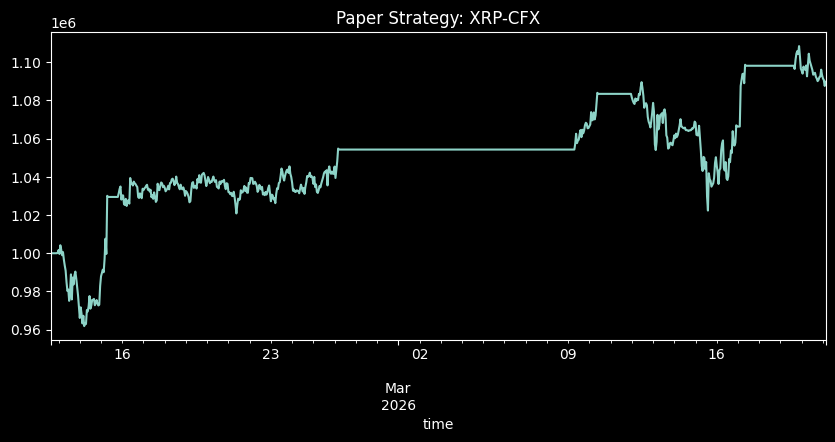


Testing ADA-AVAX with window=720...
--- Backtest Results for ADA-AVAX ---
Total Trades: 8
Final Equity: $1,004,178.51
Total Return: 0.42%
Max Drawdown Deactivated: False



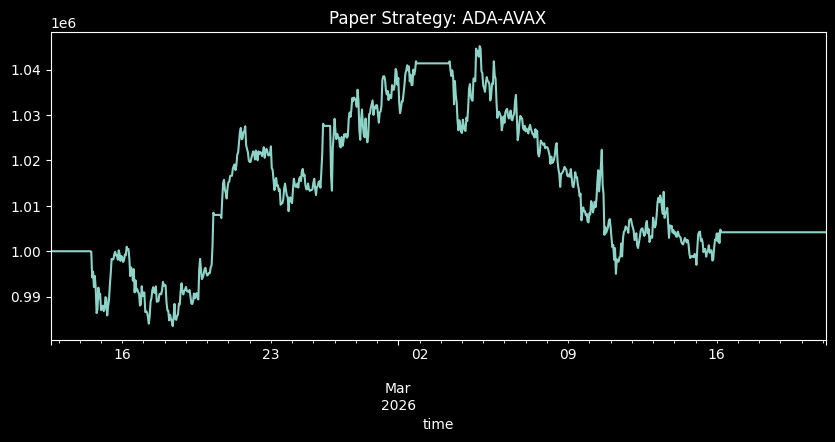


Testing CAKE-LISTA with window=720...
--- Backtest Results for CAKE-LISTA ---
Total Trades: 7
Final Equity: $1,092,526.08
Total Return: 9.25%
Max Drawdown Deactivated: False



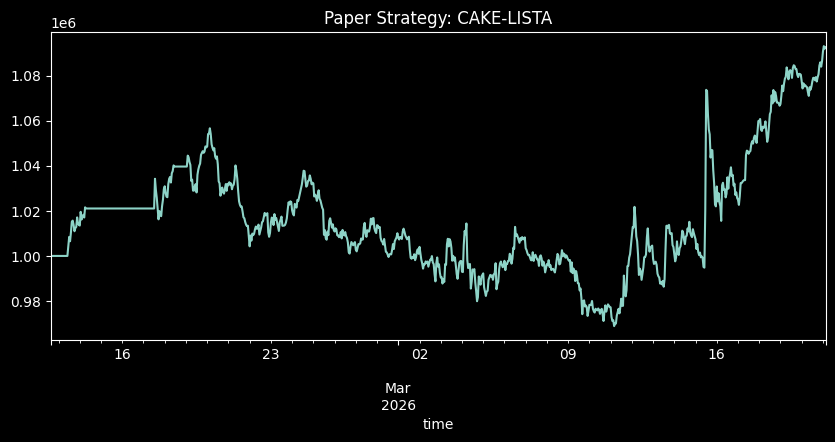


Testing LTC-XLM with window=720...
--- Backtest Results for LTC-XLM ---
Total Trades: 10
Final Equity: $1,050,539.79
Total Return: 5.05%
Max Drawdown Deactivated: False



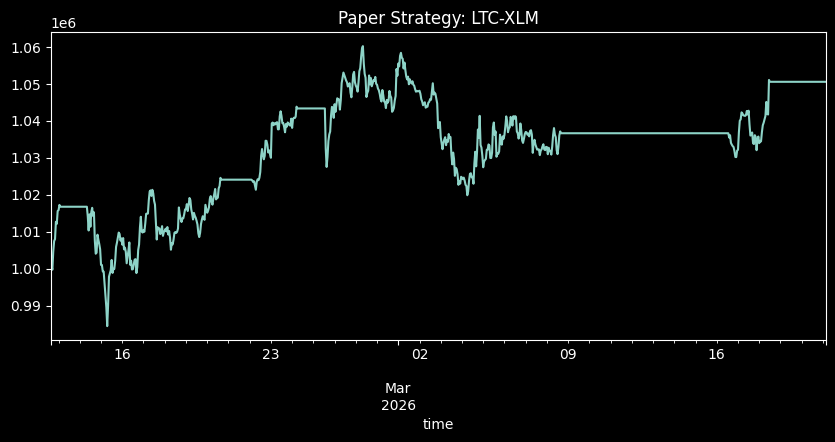


Testing XRP-XLM with window=720...
--- Backtest Results for XRP-XLM ---
Total Trades: 14
Final Equity: $1,099,579.21
Total Return: 9.96%
Max Drawdown Deactivated: False



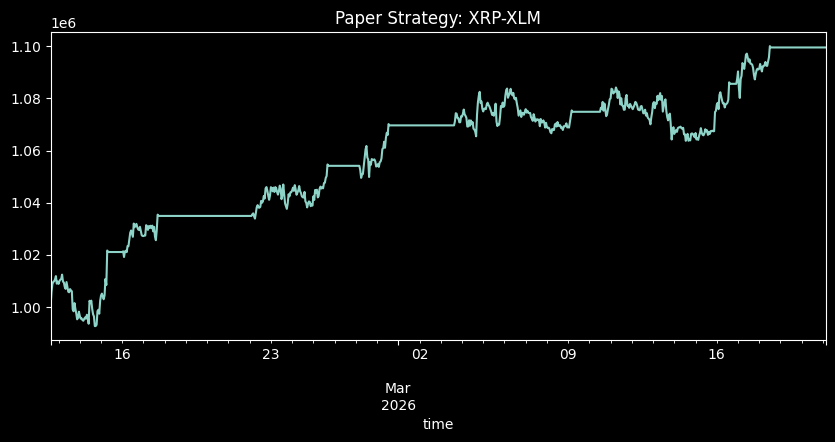


Testing DOT-APT with window=720...
--- Backtest Results for DOT-APT ---
Total Trades: 3
Final Equity: $949,122.35
Total Return: -5.09%
Max Drawdown Deactivated: False



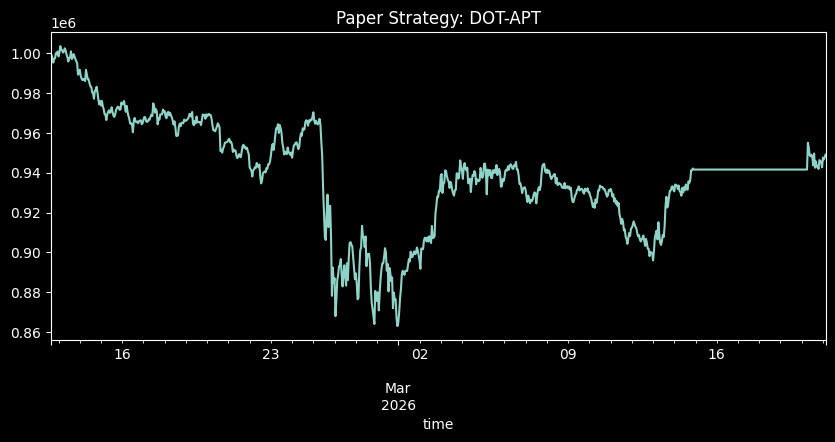


Testing BONK-FLOKI with window=360...
--- Backtest Results for BONK-FLOKI ---
Total Trades: 21
Final Equity: $1,104,272.66
Total Return: 10.43%
Max Drawdown Deactivated: False



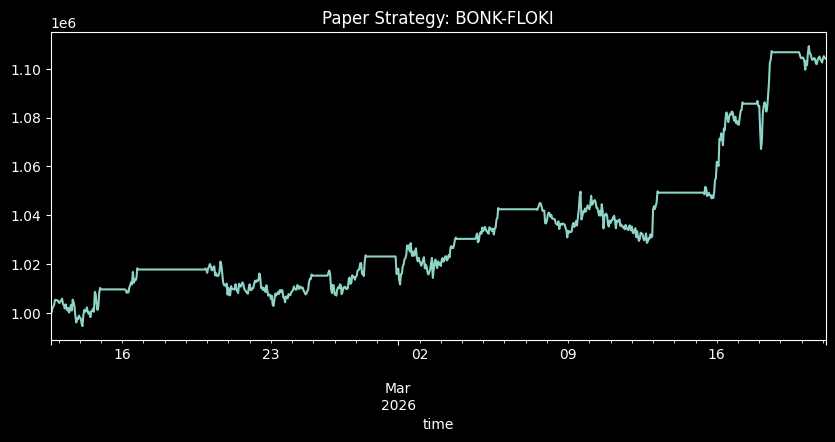


Testing AVAX-DOGE with window=720...
--- Backtest Results for AVAX-DOGE ---
Total Trades: 9
Final Equity: $1,036,755.33
Total Return: 3.68%
Max Drawdown Deactivated: False



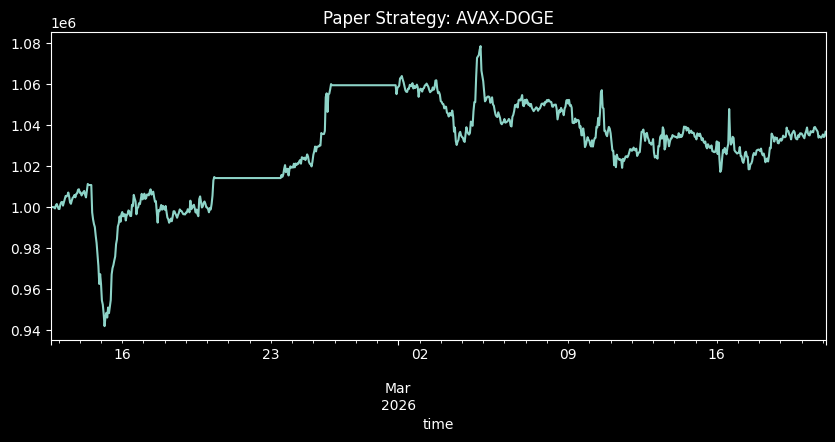


Testing PENDLE-EIGEN with window=360...
--- Backtest Results for PENDLE-EIGEN ---
Total Trades: 12
Final Equity: $1,037,366.91
Total Return: 3.74%
Max Drawdown Deactivated: False



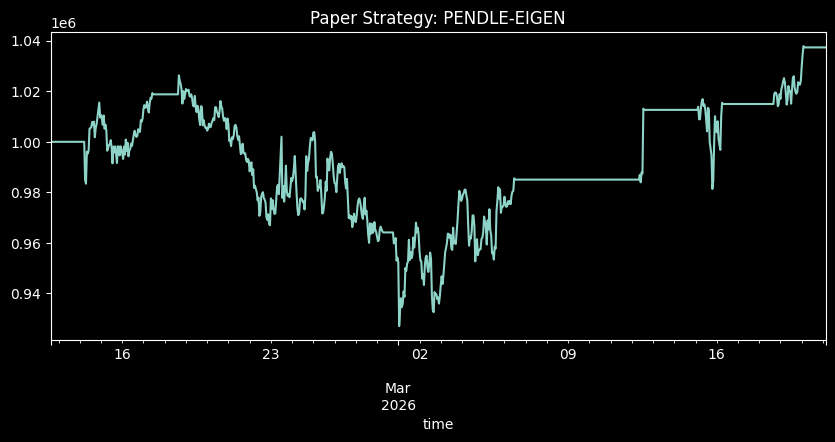


Testing XRP-LTC with window=720...
--- Backtest Results for XRP-LTC ---
Total Trades: 7
Final Equity: $1,069,577.77
Total Return: 6.96%
Max Drawdown Deactivated: False



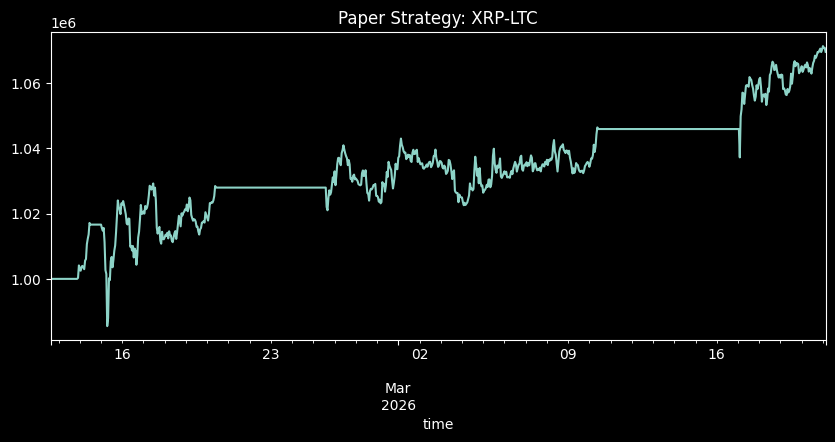

In [170]:
# Assuming 'results_df' is the dataframe from your IC test containing your top pairs
for index, row in results_df.iterrows():
    pair_str = row['Pair']
    coin_a, coin_b = pair_str.split('-')
    
    # Dynamically pull the Best T1 window found for this specific pair
    best_window = int(row['Best T1 (hours)'])
    
    warmup_data = train_close_prices.iloc[-best_window:]
    stitched_test_data = pd.concat([warmup_data, test_close_prices])
    stitched_test_data = stitched_test_data[~stitched_test_data.index.duplicated(keep='last')]
    
    print(f"\nTesting {coin_a}-{coin_b} with window={best_window}...")
    
    # Run the backtest using the stitched data and the dynamic window
    equity_curve, trade_history = run_paper_backtest(
        coin_a=coin_a, 
        coin_b=coin_b, 
        price_df=stitched_test_data, 
        window=best_window,    # <--- Now it uses the specific best window
        z_entry=1.5,           # You can still hardcode this or optimize it later
        z_exit=0.0      
    )
    
    # Note: The first 'best_window' hours will just be the bot doing math silently.
    # It will only start trading during the actual out-of-sample dates.
    
    # Plot the equity curve to visualize performance
    equity_curve['equity'].plot(figsize=(10, 4), title=f"Paper Strategy: {coin_a}-{coin_b}")
    plt.show()

# Long only backtest (competition setup)

In [171]:
def run_long_only_backtest(coin_a, coin_b, price_df, window=720, z_entry=2.0, z_exit=0.0, 
                           stop_loss_pct=0.15, cooldown_hours=120, starting_capital=100000.0, 
                           fee_rate=0.001):
    """
    Simulates a long-only relative value strategy on Roostoo mock exchange.
    Includes Total Return, Sharpe Ratio, and Sortino Ratio.
    """
    
    # 1. Calculate the rolling Z-Score
    log_prices = np.log(price_df[[coin_a, coin_b]]).dropna()
    y = log_prices[coin_a]
    x_col = log_prices[coin_b]
    X = sm.add_constant(x_col)
    
    roll_reg = RollingOLS(y, X, window=window).fit()
    params = roll_reg.params
    
    current_spread = y - (params['const'] + params[coin_b] * x_col)
    spread_std = np.sqrt(roll_reg.mse_resid)
    z_score = (current_spread / spread_std).dropna()
    
    aligned_prices = price_df.loc[z_score.index]
    
    # 2. Backtest State Tracking
    capital = starting_capital
    position = None 
    entry_price = 0.0
    units_held = 0.0
    cooldown_until = None
    
    equity_curve = []
    trades = []
    
    # 3. Time-Step Simulation
    for current_time, z in z_score.items():
        price_a = aligned_prices.loc[current_time, coin_a]
        price_b = aligned_prices.loc[current_time, coin_b]
        
        current_equity = capital
        if position == 'LONG_A':
            current_equity += units_held * price_a
        elif position == 'LONG_B':
            current_equity += units_held * price_b
            
        equity_curve.append({'time': current_time, 'equity': current_equity})
        
        if cooldown_until is not None and current_time < cooldown_until:
            continue
        elif cooldown_until is not None:
            cooldown_until = None
            
        if position is None:
            if z < -z_entry:
                position = 'LONG_A'
                entry_price = price_a
                units_held = (capital * (1 - fee_rate)) / entry_price
                capital = 0.0
                trades.append({'time': current_time, 'type': 'BUY_A', 'price': entry_price, 'z': z})
            elif z > z_entry:
                position = 'LONG_B'
                entry_price = price_b
                units_held = (capital * (1 - fee_rate)) / entry_price
                capital = 0.0
                trades.append({'time': current_time, 'type': 'BUY_B', 'price': entry_price, 'z': z})
        else:
            if position == 'LONG_A':
                unrealized_return = (price_a - entry_price) / entry_price
                if unrealized_return <= -stop_loss_pct:
                    capital = units_held * price_a * (1 - fee_rate)
                    units_held = 0.0
                    position = None
                    cooldown_until = current_time + pd.Timedelta(hours=cooldown_hours)
                    trades.append({'time': current_time, 'type': 'STOP_LOSS_A', 'price': price_a, 'return': unrealized_return})
                elif z >= -z_exit:
                    capital = units_held * price_a * (1 - fee_rate)
                    units_held = 0.0
                    position = None
                    trades.append({'time': current_time, 'type': 'SELL_A', 'price': price_a, 'return': unrealized_return})
            elif position == 'LONG_B':
                unrealized_return = (price_b - entry_price) / entry_price
                if unrealized_return <= -stop_loss_pct:
                    capital = units_held * price_b * (1 - fee_rate)
                    units_held = 0.0
                    position = None
                    cooldown_until = current_time + pd.Timedelta(hours=cooldown_hours)
                    trades.append({'time': current_time, 'type': 'STOP_LOSS_B', 'price': price_b, 'return': unrealized_return})
                elif z <= z_exit:
                    capital = units_held * price_b * (1 - fee_rate)
                    units_held = 0.0
                    position = None
                    trades.append({'time': current_time, 'type': 'SELL_B', 'price': price_b, 'return': unrealized_return})

    # 4. Wrap up results and calculate Risk Metrics
    equity_df = pd.DataFrame(equity_curve).set_index('time')
    trades_df = pd.DataFrame(trades)
    
    # Calculate returns for Sharpe/Sortino
    # Assuming data is hourly, annualize by sqrt(24 * 365)
    returns = equity_df['equity'].pct_change().dropna()
    ann_factor = np.sqrt(24 * 365) 
    
    sharpe_ratio = 0
    sortino_ratio = 0
    
    if len(returns) > 0 and returns.std() != 0:
        sharpe_ratio = (returns.mean() / returns.std()) * ann_factor
        
        downside_returns = returns[returns < 0]
        if len(downside_returns) > 0 and downside_returns.std() != 0:
            sortino_ratio = (returns.mean() / downside_returns.std()) * ann_factor

    total_return = (equity_df['equity'].iloc[-1] - starting_capital) / starting_capital
    
    print(f"--- Backtest Results for {coin_a}-{coin_b} ---")
    print(f"Total Trades: {len(trades_df)}")
    print(f"Total Return: {total_return * 100:.2f}%")
    print(f"Sharpe Ratio: {sharpe_ratio:.4f}")
    print(f"Sortino Ratio: {sortino_ratio:.4f}")
    print(f"Final Equity: ${equity_df['equity'].iloc[-1]:.2f}\n")
    
    return equity_df, trades_df, sharpe_ratio

## Optimize parameters within training data

In [172]:
def grid_search_z_params(coin_a, coin_b, price_df, window=720, 
                        z_entry_range=[1.5, 2.0, 2.5, 3.0], 
                        z_exit_range=[0.0, 0.5, 1.0]):
    """
    Performs a grid search to find the optimal z_entry and z_exit parameters.
    """
    results = []
    
    print(f"Starting Grid Search for {coin_a}-{coin_b}...")
    
    for z_entry in z_entry_range:
        for z_exit in z_exit_range:
            # We only care about cases where the entry barrier is wider than the exit
            if z_exit >= z_entry:
                continue
                
            equity_df, trades_df, sharpe_ratio = run_long_only_backtest(
                coin_a=coin_a,
                coin_b=coin_b,
                price_df=price_df,
                window=window,
                z_entry=z_entry,
                z_exit=z_exit,
                starting_capital=100000.0
            )
            
            # Calculate metrics
            final_equity = equity_df['equity'].iloc[-1]
            total_return = (final_equity - 100000.0) / 100000.0
            num_trades = len(trades_df)
            
            results.append({
                'z_entry': z_entry,
                'z_exit': z_exit,
                'total_return': total_return,
                'sharpe_ratio': sharpe_ratio,
                'num_trades': num_trades,
                'final_equity': final_equity
            })
            
            print(f"Tested: z_entry={z_entry}, z_exit={z_exit} | Return: {total_return*100:.2f}% | Sharpe: {sharpe_ratio} | Trades: {num_trades}")

    results_df = pd.DataFrame(results)
    
    if not results_df.empty:
        best_result = results_df.sort_values(by='sharpe_ratio', ascending=False).iloc[0]
        print("\n" + "="*30)
        print("--- Best Parameters Found ---")
        print(f"z_entry: {best_result['z_entry']}")
        print(f"z_exit:  {best_result['z_exit']}")
        print(f"Sharpe: {best_result['sharpe_ratio']}")
        print(f"Total Return: {best_result['total_return']*100:.2f}%")
        print(f"Number of Trades: {best_result['num_trades']}")
        print("="*30)
    
    return results_df

In [173]:
# 1. Initialize new columns with NaN (to make filtering easier at the end)
import numpy as np
results_df['Optimized_z_entry'] = np.nan
results_df['Optimized_z_exit'] = np.nan

# Dictionary to store final backtest data
final_backtest_results = {}

print(f"Starting optimization for {len(results_df)} pairs...")

for index, row in results_df.iterrows():
    pair_str = row['Pair']
    coin_a, coin_b = pair_str.split('-')
    best_window = int(row['Best T1 (hours)'])
    
    print(f"\n>>> Step 1: Grid-searching z-score for {pair_str} with window={best_window}...")
    
    gs_results = grid_search_z_params(
        coin_a=coin_a, 
        coin_b=coin_b, 
        price_df=train_close_prices, 
        window=best_window
    )
    
    # 2. Extract and check the best parameters found
    if not gs_results.empty:
        best_row = gs_results.sort_values(by='sharpe_ratio', ascending=False).iloc[0]
        
        # # --- NEW FILTERING LOGIC ---
        # # If the best Sharpe is 0 or negative, we don't use this pair.
        # if best_row['sharpe_ratio'] <= 0:
        #     print(f"!!! Skipping {pair_str}: Best Sharpe found was {best_row['sharpe_ratio']:.4f}. Not profitable.")
        #     continue 
        # # ---------------------------

        opt_z_entry = best_row['z_entry']
        opt_z_exit = best_row['z_exit']
        
        # Save these to our master results_df
        results_df.at[index, 'Optimized_z_entry'] = opt_z_entry
        results_df.at[index, 'Optimized_z_exit'] = opt_z_exit
        
        print(f"Optimal for {pair_str}: entry={opt_z_entry}, exit={opt_z_exit} (Sharpe: {best_row['sharpe_ratio']:.4f})")

        # 3. Step 2: Run the FINAL backtest for this profitable pair
        print(f">>> Step 2: Running final backtest for {pair_str}...")
        equity_df, trades_df, final_sharpe = run_long_only_backtest(
            coin_a=coin_a,
            coin_b=coin_b,
            price_df=train_close_prices,
            window=best_window,
            z_entry=opt_z_entry,
            z_exit=opt_z_exit,
            starting_capital=100000.0
        )
        
        final_backtest_results[pair_str] = {
            'equity': equity_df,
            'trades': trades_df,
            'sharpe': final_sharpe,
            'z_entry': opt_z_entry,
            'z_exit': opt_z_exit
        }

# 4. FINAL CLEANUP: Remove any pairs from results_df that were skipped (remains as NaN)
results_df = results_df.dropna(subset=['Optimized_z_entry']).reset_index(drop=True)

print(f"\nOptimization complete. Kept {len(results_df)} pairs.")


Starting optimization for 10 pairs...

>>> Step 1: Grid-searching z-score for XRP-CFX with window=720...
Starting Grid Search for XRP-CFX...
--- Backtest Results for XRP-CFX ---
Total Trades: 64
Total Return: -38.01%
Sharpe Ratio: -0.6040
Sortino Ratio: -0.6386
Final Equity: $61993.83

Tested: z_entry=1.5, z_exit=0.0 | Return: -38.01% | Sharpe: -0.6039983304683461 | Trades: 64
--- Backtest Results for XRP-CFX ---
Total Trades: 76
Total Return: -33.56%
Sharpe Ratio: -0.5657
Sortino Ratio: -0.5396
Final Equity: $66441.02

Tested: z_entry=1.5, z_exit=0.5 | Return: -33.56% | Sharpe: -0.5657405825760452 | Trades: 76
--- Backtest Results for XRP-CFX ---
Total Trades: 98
Total Return: -21.79%
Sharpe Ratio: -0.3666
Sortino Ratio: -0.2913
Final Equity: $78207.31

Tested: z_entry=1.5, z_exit=1.0 | Return: -21.79% | Sharpe: -0.3665645430186394 | Trades: 98
--- Backtest Results for XRP-CFX ---
Total Trades: 52
Total Return: -13.04%
Sharpe Ratio: -0.0509
Sortino Ratio: -0.0472
Final Equity: $86963.


Testing XRP-CFX with window=720 hours, z_entry=2.5, z_exit=0.5
--- Backtest Results for XRP-CFX ---
Total Trades: 11
Total Return: 33.48%
Sharpe Ratio: 7.0883
Sortino Ratio: 8.4178
Final Equity: $133483.57



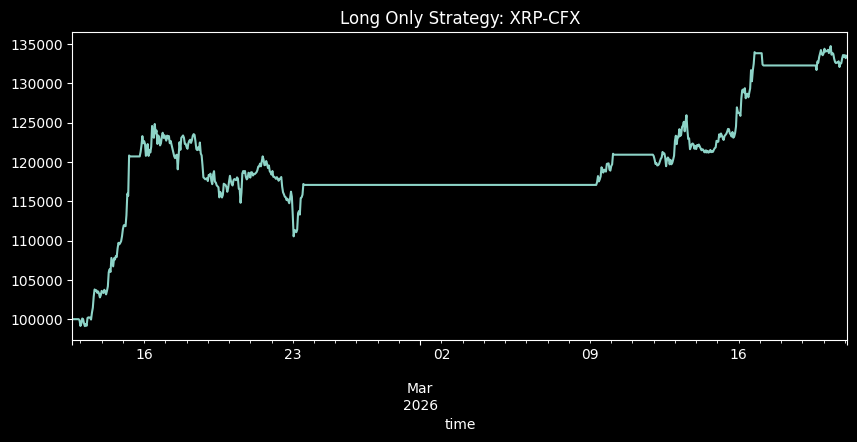


Testing ADA-AVAX with window=720 hours, z_entry=2.5, z_exit=0.5
--- Backtest Results for ADA-AVAX ---
Total Trades: 10
Total Return: -3.58%
Sharpe Ratio: -0.4256
Sortino Ratio: -0.5314
Final Equity: $96415.44



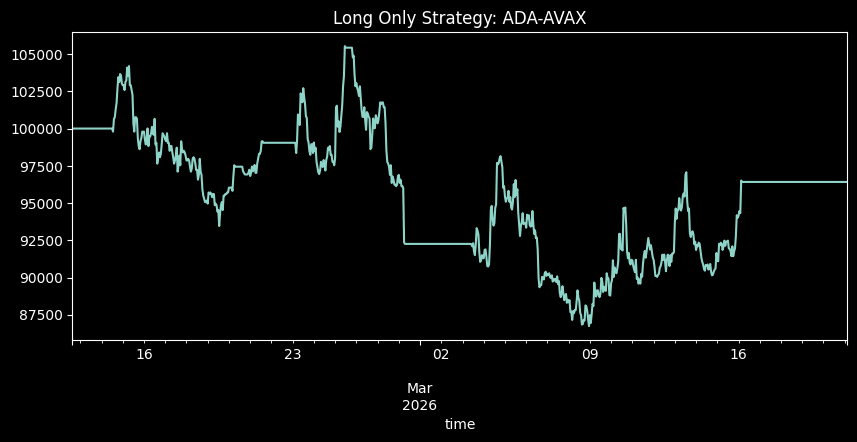


Testing CAKE-LISTA with window=720 hours, z_entry=2.0, z_exit=1.0
--- Backtest Results for CAKE-LISTA ---
Total Trades: 14
Total Return: 1.93%
Sharpe Ratio: 0.6285
Sortino Ratio: 0.8261
Final Equity: $101931.57



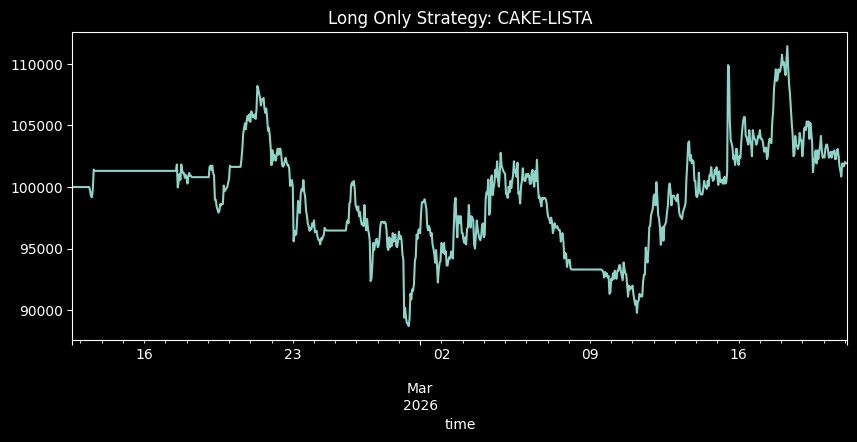


Testing LTC-XLM with window=720 hours, z_entry=3.0, z_exit=0.5
--- Backtest Results for LTC-XLM ---
Total Trades: 14
Total Return: -3.94%
Sharpe Ratio: -0.7879
Sortino Ratio: -0.6612
Final Equity: $96057.56



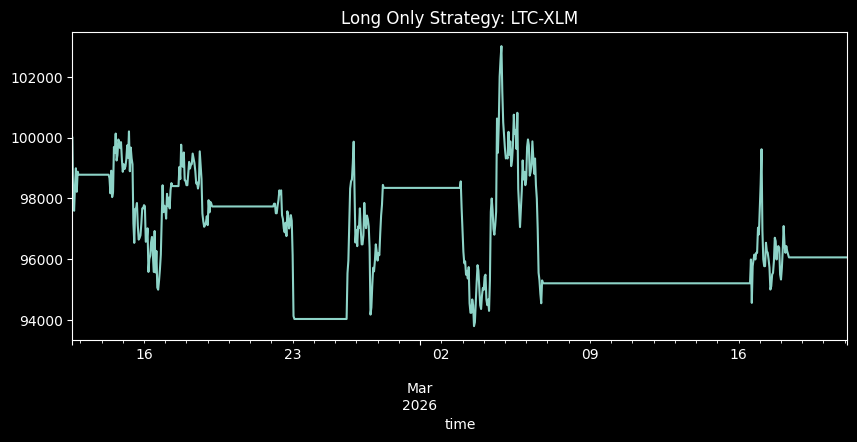


Testing XRP-XLM with window=720 hours, z_entry=2.0, z_exit=0.0
--- Backtest Results for XRP-XLM ---
Total Trades: 20
Total Return: 28.60%
Sharpe Ratio: 5.8987
Sortino Ratio: 5.6750
Final Equity: $128604.47



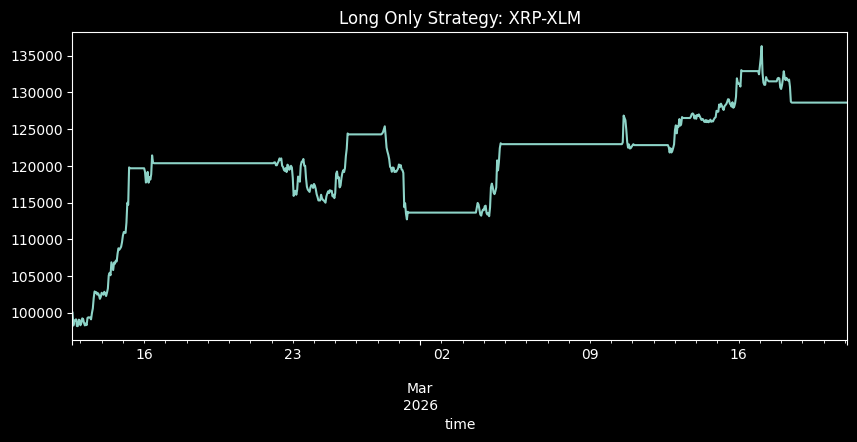


Testing DOT-APT with window=720 hours, z_entry=3.0, z_exit=1.0
--- Backtest Results for DOT-APT ---
Total Trades: 5
Total Return: -6.92%
Sharpe Ratio: -0.6202
Sortino Ratio: -0.7323
Final Equity: $93081.61



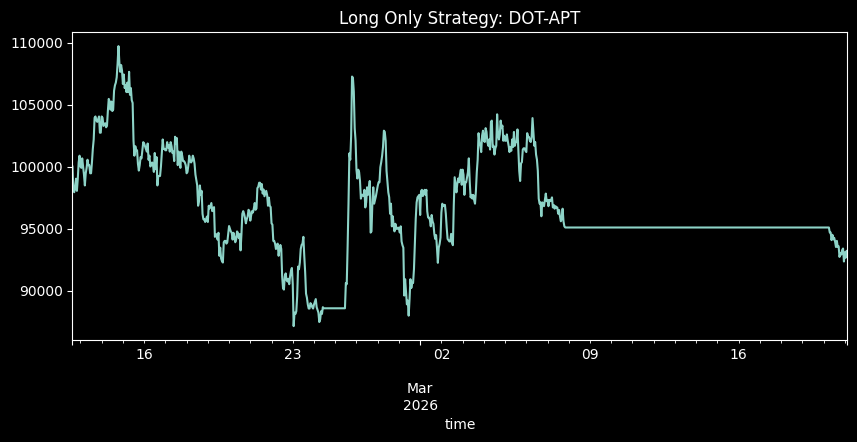


Testing BONK-FLOKI with window=360 hours, z_entry=3.0, z_exit=0.0
--- Backtest Results for BONK-FLOKI ---
Total Trades: 29
Total Return: 18.29%
Sharpe Ratio: 3.0016
Sortino Ratio: 3.5886
Final Equity: $118287.57



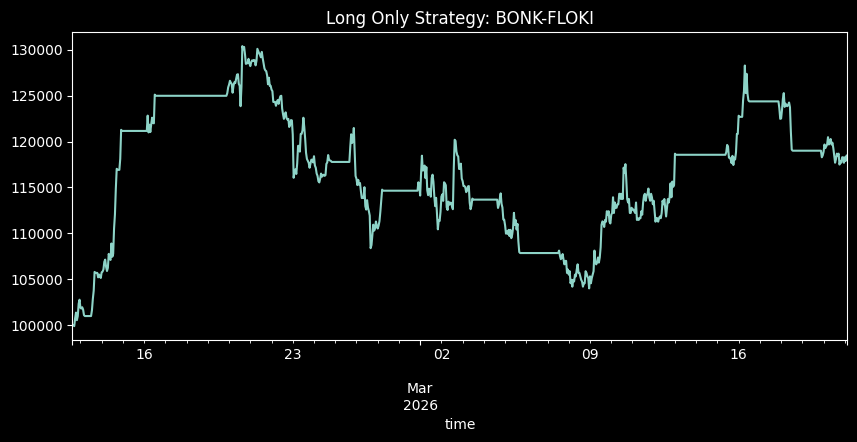


Testing AVAX-DOGE with window=720 hours, z_entry=2.0, z_exit=0.0
--- Backtest Results for AVAX-DOGE ---
Total Trades: 11
Total Return: 4.35%
Sharpe Ratio: 1.0072
Sortino Ratio: 1.3217
Final Equity: $104353.97



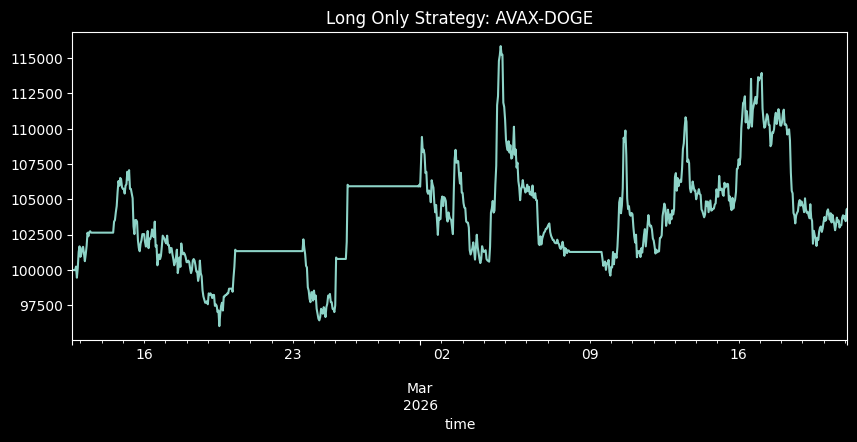


Testing PENDLE-EIGEN with window=360 hours, z_entry=2.5, z_exit=0.5
--- Backtest Results for PENDLE-EIGEN ---
Total Trades: 16
Total Return: -8.50%
Sharpe Ratio: -1.3260
Sortino Ratio: -1.1992
Final Equity: $91502.01



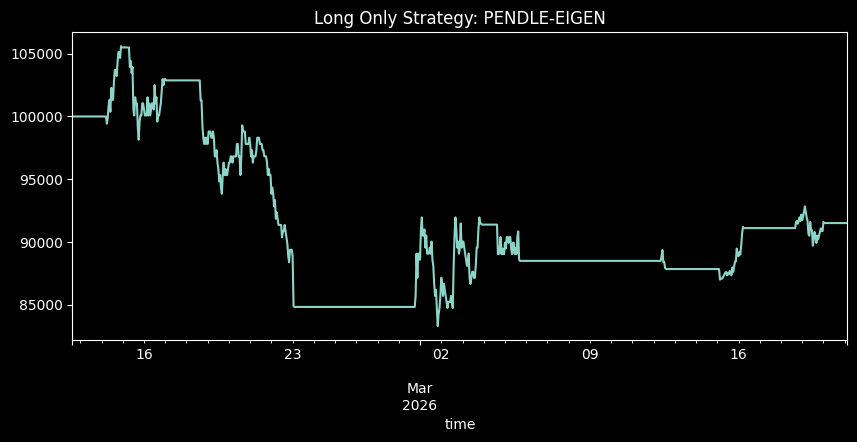


Testing XRP-LTC with window=720 hours, z_entry=1.5, z_exit=0.5
--- Backtest Results for XRP-LTC ---
Total Trades: 10
Total Return: -5.58%
Sharpe Ratio: -1.1169
Sortino Ratio: -1.0173
Final Equity: $94415.67



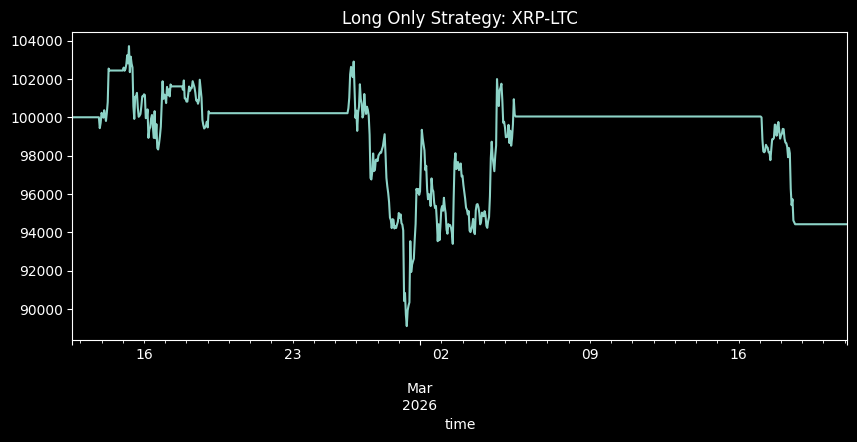

In [174]:
# Assuming 'results_df' is the dataframe from your IC test containing your top pairs
for index, row in results_df.iterrows():
    pair_str = row['Pair']
    coin_a, coin_b = pair_str.split('-')
    
    # Dynamically pull the Best T1 window found for this specific pair
    best_window = int(row['Best T1 (hours)'])
    best_z_entry = row['Optimized_z_entry']
    best_z_exit = row['Optimized_z_exit']
    
    # --- THE WARM-UP FIX ---
    # Take the exact number of hours needed from the END of the training set
    warmup_data = train_close_prices.iloc[-best_window:]
    
    # Attach the test set to the end of the warm-up data
    stitched_test_data = pd.concat([warmup_data, test_close_prices])
    # -----------------------
    
    print(f"\nTesting {coin_a}-{coin_b} with window={best_window} hours, z_entry={best_z_entry}, z_exit={best_z_exit}")
    
    # Run the backtest using the stitched data and the dynamic window
    equity_curve, trade_history, sharpe_ratio = run_long_only_backtest(
        coin_a=coin_a, 
        coin_b=coin_b, 
        price_df=stitched_test_data, 
        window=best_window,
        z_entry=1.5,
        z_exit=0.5      
    )
    
    # Note: The first 'best_window' hours will just be the bot doing math silently.
    # It will only start trading during the actual out-of-sample dates.
    
    # Plot the equity curve to visualize performance
    equity_curve['equity'].plot(figsize=(10, 4), title=f"Long Only Strategy: {coin_a}-{coin_b}")
    plt.show()

# Final backtest: Simulate entire portfolio (long-only)
Assuming each pair gets an equal capital allocation

Starting aggregated portfolio backtest for 10 pairs...
Allocation per pair: $100,000.00

--- Backtest Results for XRP-CFX ---
Total Trades: 11
Total Return: 33.48%
Sharpe Ratio: 7.0883
Sortino Ratio: 8.4178
Final Equity: $133483.57

--- Backtest Results for ADA-AVAX ---
Total Trades: 10
Total Return: -3.58%
Sharpe Ratio: -0.4256
Sortino Ratio: -0.5314
Final Equity: $96415.44

--- Backtest Results for CAKE-LISTA ---
Total Trades: 14
Total Return: 1.93%
Sharpe Ratio: 0.6285
Sortino Ratio: 0.8261
Final Equity: $101931.57

--- Backtest Results for LTC-XLM ---
Total Trades: 14
Total Return: -3.94%
Sharpe Ratio: -0.7879
Sortino Ratio: -0.6612
Final Equity: $96057.56

--- Backtest Results for XRP-XLM ---
Total Trades: 20
Total Return: 28.60%
Sharpe Ratio: 5.8987
Sortino Ratio: 5.6750
Final Equity: $128604.47

--- Backtest Results for DOT-APT ---
Total Trades: 5
Total Return: -6.92%
Sharpe Ratio: -0.6202
Sortino Ratio: -0.7323
Final Equity: $93081.61

--- Backtest Results for BONK-FLOKI ---
To

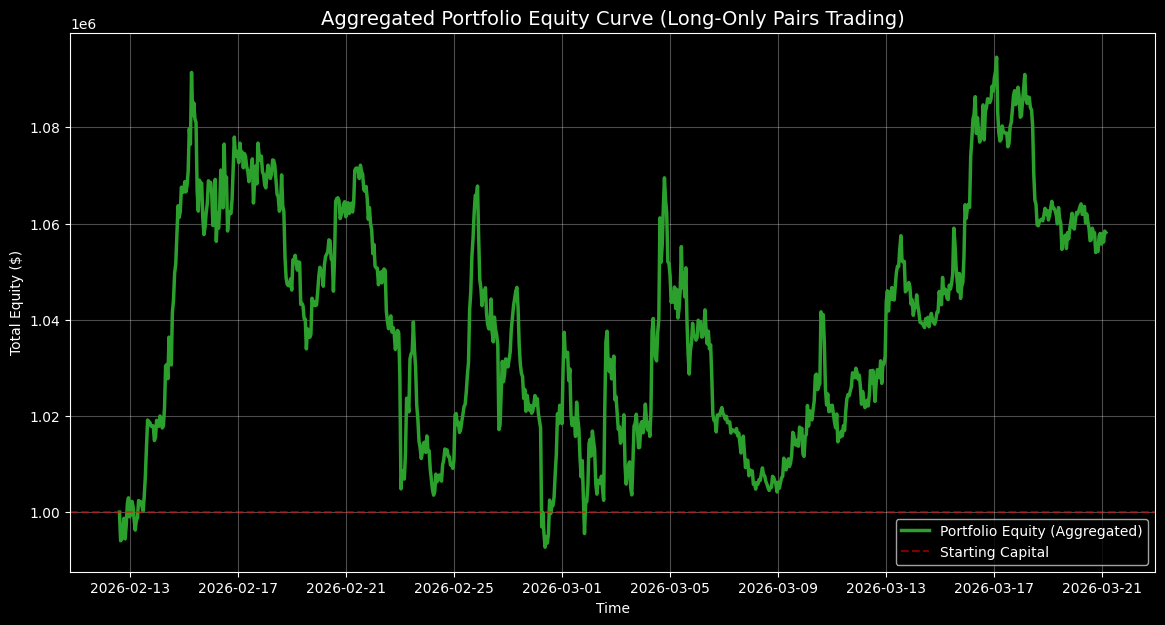

In [198]:
# 2. Portfolio Configuration (Corrected)
total_portfolio_capital = 1000000.0  # $1,000,000 for the whole portfolio
capital_per_pair = total_portfolio_capital / len(results_df)

individual_equities = []
all_trades = []

print(f"Starting aggregated portfolio backtest for {len(results_df)} pairs...")
print(f"Allocation per pair: ${capital_per_pair:,.2f}\n")

for idx, row in results_df.iterrows():
    pair_name = row['Pair']
    coin_a, coin_b = pair_name.split('-')
    best_window = int(row['Best T1 (hours)'])
    best_z_entry = row['Optimized_z_entry']
    best_z_exit = row['Optimized_z_exit']

    WINDOW = best_window
    Z_ENTRY = 1.5
    Z_EXIT = 0.5
    STOP_LOSS_PCT = 0.15
    
    
    # --- FIX: Rebuild stitched data for EACH pair inside the loop ---
    # Take the exact number of hours needed from the END of the training set
    warmup_data = train_close_prices.iloc[-WINDOW:]
    
    # Attach the test set to the end of the warm-up data
    # This ensures the backtest always has enough data to start trading at the beginning of the test set
    stitched_test_data = pd.concat([warmup_data, test_close_prices])
    # -----------------------------------------------------------------
    
    # Run backtest for this specific pair
    equity_df, trades_df, sharpe_ratio = run_long_only_backtest(
        coin_a=coin_a,
        coin_b=coin_b,
        price_df=stitched_test_data,
        window=WINDOW,
        z_entry=Z_ENTRY,
        z_exit=Z_EXIT,
        stop_loss_pct=STOP_LOSS_PCT,
        starting_capital=capital_per_pair
    )
    
    # Rename column to avoid collision when merging
    equity_series = equity_df['equity'].rename(f'equity_{pair_name}')
    individual_equities.append(equity_series)
    all_trades.append(trades_df)

# 3. Aggregate results into a single DataFrame
# Using 'inner' join equivalent via dropna() ensures we only plot the overlapping test period
portfolio_equity_df = pd.concat(individual_equities, axis=1)
portfolio_equity_df = portfolio_equity_df.ffill().dropna()

# Calculate total portfolio equity
portfolio_equity_df['total_equity'] = portfolio_equity_df.sum(axis=1)


# 4. Calculate Aggregate Risk Metrics
p_returns = portfolio_equity_df['total_equity'].pct_change().dropna()
# Hourly data annualization factor
ann_factor = np.sqrt(24 * 365) 

p_sharpe = 0
p_sortino = 0
if p_returns.std() != 0:
    p_sharpe = (p_returns.mean() / p_returns.std()) * ann_factor
    
    p_downside = p_returns[p_returns < 0]
    if len(p_downside) > 0 and p_downside.std() != 0:
        p_sortino = (p_returns.mean() / p_downside.std()) * ann_factor

final_portfolio_equity = portfolio_equity_df['total_equity'].iloc[-1]
portfolio_total_return = (final_portfolio_equity - total_portfolio_capital) / total_portfolio_capital

# 5. Display Summary
print("\n" + "="*45)
print("--- AGGREGATED PORTFOLIO PERFORMANCE ---")
print(f"Initial Investment: ${total_portfolio_capital:,.2f}")
print(f"Final Equity:      ${final_portfolio_equity:,.2f}")
print(f"Total Return:      {portfolio_total_return * 100:.2f}%")
print(f"Portfolio Sharpe:  {p_sharpe:.4f}")
print(f"Portfolio Sortino: {p_sortino:.4f}")
print(f"Total Combined Trades: {sum(len(t) for t in all_trades)}")
print("="*45)

# 6. Plot the Portfolio Equity Curve
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))
plt.plot(portfolio_equity_df['total_equity'], label='Portfolio Equity (Aggregated)', color='#2ca02c', linewidth=2.5)
plt.axhline(y=total_portfolio_capital, color='red', linestyle='--', alpha=0.5, label='Starting Capital')
plt.title('Aggregated Portfolio Equity Curve (Long-Only Pairs Trading)', fontsize=14)
plt.ylabel('Total Equity ($)')
plt.xlabel('Time')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [202]:
len(results_df)

10

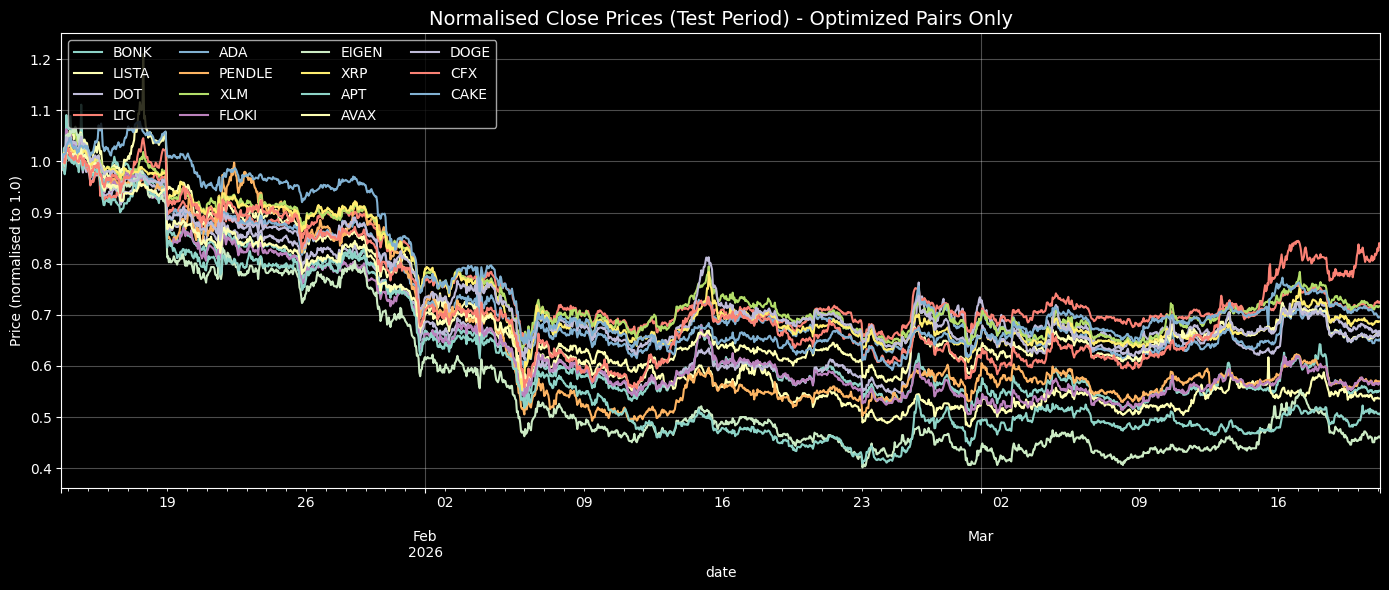

In [200]:
# Normalise all series to start at 1.0 for visual comparison
normalised = stitched_test_data / stitched_test_data.iloc[0]

# Extract all unique coins from the 'Pair' column in results_df
trading_coins = list(set([coin for pair_str in results_df['Pair'] for coin in pair_str.split('-')]))

# Ensure we only pick coins that actually exist in the dataframe columns
trading_coins = [c for c in trading_coins if c in normalised.columns]
filtered_normalised = normalised[trading_coins]

# Plot the filtered data
fig, ax = plt.subplots(figsize=(14, 6))
filtered_normalised.plot(ax=ax, linewidth=1.5)

ax.set_title(f"Normalised Close Prices (Test Period) - Optimized Pairs Only", fontsize=14)
ax.set_ylabel("Price (normalised to 1.0)")
ax.legend(loc="upper left", ncol=4)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# Generate config file

In [ ]:
import json
import os

# 1. Define Strategy Parameters
z_entry_threshold = 1.5
z_exit_threshold = 0.5
stop_loss_pct = 0.15
cooldown_hours = 120
allocated_capital = 100000

# 2. Build the trading_pairs list dynamically from results_df
trading_pairs = []
for idx, row in results_df.iterrows():
    pair_name = row['Pair']
    coin_a, coin_b = pair_name.split('-')
    # Best T1 (hours) was our optimized window size
    window_size = int(row['Best T1 (hours)'])
    
    trading_pairs.append({
        "coin_a": coin_a,
        "coin_b": coin_b,
        "window_size": window_size,
        "allocated_capital": allocated_capital
    })

# 3. Construct the full configuration dictionary
config_data = {
    "strategy_parameters": {
        "z_entry_threshold": z_entry_threshold,
        "z_exit_threshold": z_exit_threshold,
        "stop_loss_pct": stop_loss_pct,
        "cooldown_hours": cooldown_hours
    },
    "trading_pairs": trading_pairs
}

# 4. Save to JSON file
config_file_path = "config.json"

with open(config_file_path, 'w') as f:
    json.dump(config_data, f, indent=2)

print(f"✅ Successfully exported {len(trading_pairs)} pairs to {config_file_path}")

# Optional: Print the JSON output to the cell for verification
print(json.dumps(config_data, indent=2))

✅ Successfully exported 10 pairs to config.json
{
  "strategy_parameters": {
    "z_entry_threshold": 1.5,
    "z_exit_threshold": 0.5,
    "stop_loss_pct": 0.15,
    "cooldown_hours": 120
  },
  "trading_pairs": [
    {
      "coin_a": "XRP",
      "coin_b": "CFX",
      "window_size": 720,
      "allocated_capital": 1000000
    },
    {
      "coin_a": "ADA",
      "coin_b": "AVAX",
      "window_size": 720,
      "allocated_capital": 1000000
    },
    {
      "coin_a": "CAKE",
      "coin_b": "LISTA",
      "window_size": 720,
      "allocated_capital": 1000000
    },
    {
      "coin_a": "LTC",
      "coin_b": "XLM",
      "window_size": 720,
      "allocated_capital": 1000000
    },
    {
      "coin_a": "XRP",
      "coin_b": "XLM",
      "window_size": 720,
      "allocated_capital": 1000000
    },
    {
      "coin_a": "DOT",
      "coin_b": "APT",
      "window_size": 720,
      "allocated_capital": 1000000
    },
    {
      "coin_a": "BONK",
      "coin_b": "FLOKI",
      